# **How Curvature, Dimensionality and Distributional Complexity Affect Riemannian Flow Matching**

## **Results**

- All helper utilities live in `visualize_run.py` (paths/globs, metrics I/O, and plotting).
- A run directory is expected to contain `artifacts/final_fixed_eval_outputs.pt` and `metrics.json`.

In [2]:
from visualize_run import get_metrics
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Georgia", "DejaVu Serif", "Times New Roman"],
    "mathtext.fontset": "dejavuserif",
    "axes.titlesize": 14,
    "axes.labelsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "figure.titlesize": 14,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

### Define output paths
- Specify output globs where outputs live

In [4]:
mog_paths = [
    '../outputs/runs/mog/euclidean/general/*',
    '../outputs/runs/mog/sphere/general/*',
    '../outputs/runs/mog/poincare/general/*',
]

gtg_paths = [
    '../outputs/runs/gtg/euclidean/general/*',
    '../outputs/runs/gtg/sphere/general/*',
    '../outputs/runs/gtg/poincare/general/*'
]

gaussian_ring_paths = [
    '../outputs/runs/general_fm/fm/*/*'
]

checkerboard_paths = [
    '../outputs/runs/checkerboard/euclidean/general/*',
    '../outputs/runs/checkerboard/sphere/general/*',
    '../outputs/runs/checkerboard/poincare/general/*',
]

### Load results
- Set visualize to True to save plots of final flow matching distribution.
- Results are saved to csv by default.
- Comment out ```get_method()``` lines to load results from csv.

In [5]:
# Load and save into csv (comment out if applicable)

#metrics_gtg = get_metrics([], gtg_paths, visualize=False, save=True, out_dir='runs/gtg')
# metrics_mog = get_metrics([], mog_paths, visualize=False, save=True, out_dir='runs/mog')
#metrics_gaussian_ring = get_metrics([], gaussian_ring_paths, visualize=False, save=True, out_dir='runs/gaussian_ring')
# metrics_checkerboard = get_metrics([], checkerboard_paths, visualize=False, save=True, out_dir='runs/checkerboard')

# Retrieve from csv
metrics_gtg = pd.read_csv('runs/gtg/metrics.csv')
metrics_mog = pd.read_csv('runs/mog/metrics.csv')
metrics_gaussian_ring = pd.read_csv('runs/gaussian_ring/metrics.csv')
metrics_checkerboard = pd.read_csv('runs/checkerboard/metrics.csv')

### Specify Results
- Change the experiment variable to applicable experiment
- change the x or y axis to get metrics

In [6]:
def print_metrics(experiment: pd.DataFrame, x: str, y: str):
    print(f"Available metrics:")
    print(", ".join(map(str, experiment.columns.tolist())))
    print()
    
    selected = experiment[[experiment.columns[0], x, y]]
    print(selected.to_string(index=False))

In [7]:
# metrics_gtg, metrics_mog, metrics_gaussian_ring, metrics_checkerboard
experiment = metrics_gtg
print_metrics(experiment, x='test_sample/volume_scaling_gap_target_minus_pred', y='test_sample/sinkhorn_knopp')

Available metrics:
Unnamed: 0, train/loss, train/loss_step, train/loss_epoch, nfe, integ_error, test/loss, test_vec/rfm_loss, test_vec/alignment, test_vec/finite_fraction, test_vec/norm_mean, test_vec/norm_max, test_vec/norm_std, test_vec/norm_p95, test_vec/tangency_violation_abs, test_vec/tangency_violation_rel, test_sample/sinkhorn_knopp, test_sample/tangent_sinkhorn_knopp, test_sample/tangent_to_geodesic_sinkhorn_ratio, test_sample/epsilon_coverage, test_sample/epsilon_precision, test_sample/frechet_variance_pred, test_sample/frechet_variance_target, test_sample/frechet_variance_ratio, test_sample/dispersion_predicted, test_sample/dispersion_target, test_sample/dispersion_ratio, test_sample/volume_scaling_mean_pred, test_sample/volume_scaling_mean_target, test_sample/volume_scaling_variance_pred, test_sample/volume_scaling_variance_target, test_sample/volume_scaling_gap_target_minus_pred, test_sample/volume_scaling_mean_start, test_sample/volume_scaling_variance_start, test_sample/v

In [8]:
# # average over seeds (manifold, curvature, dim are equal)
# experiment_avg = experiment.groupby(['manifold', 'dim', 'curvature'], as_index=False).mean(numeric_only=True)
# print(experiment_avg)

In [9]:
# # Convert ambient dimension to intrinsic dimension for sphere (dim - 1)
# experiment_avg_intr = experiment_avg.copy()
# experiment_avg_intr.loc[experiment_avg_intr['manifold'] == 'sphere', 'dim'] -= 1
# print(experiment_avg_intr)

### Plots RQ 1
**Main**

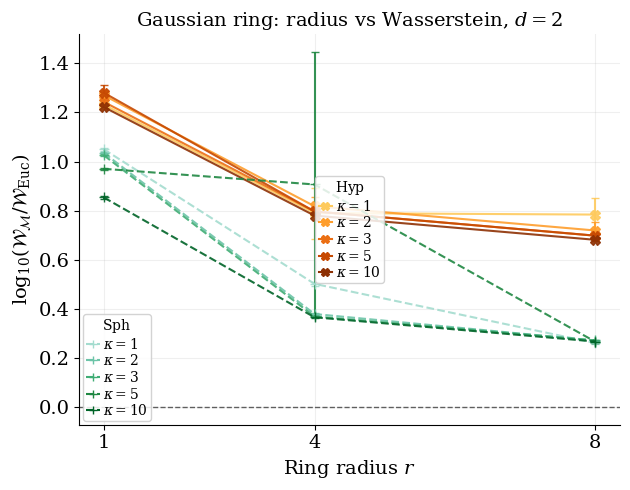

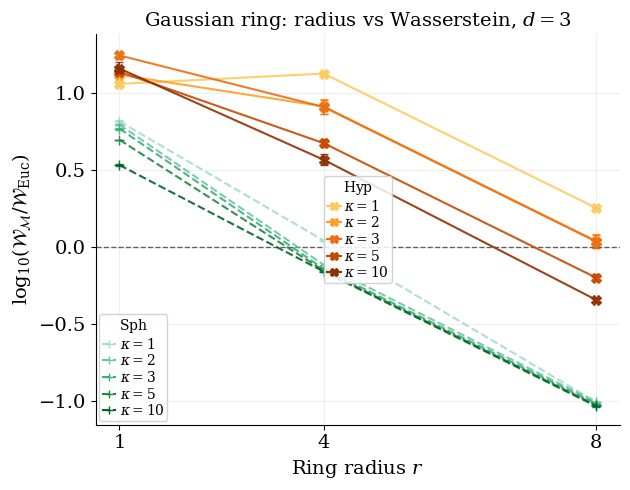

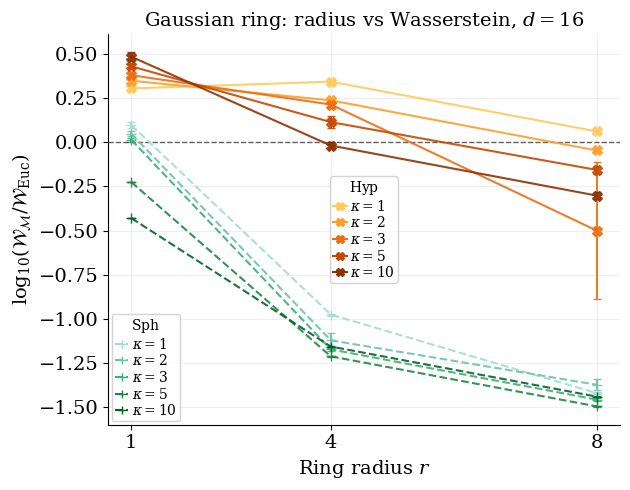

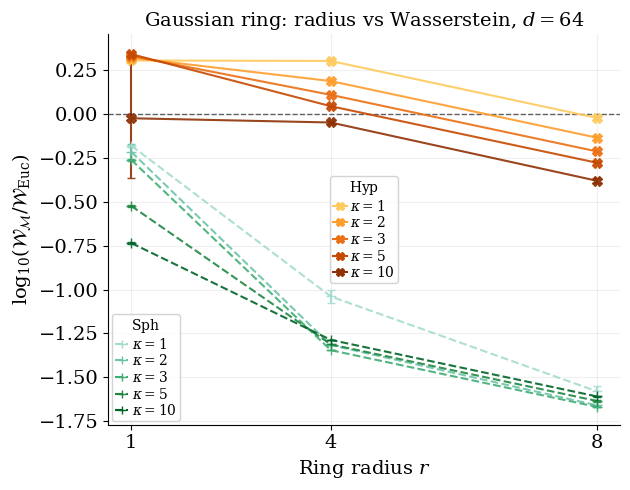

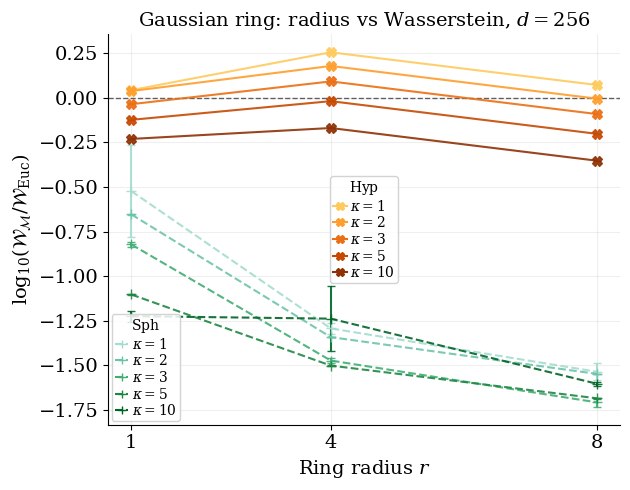

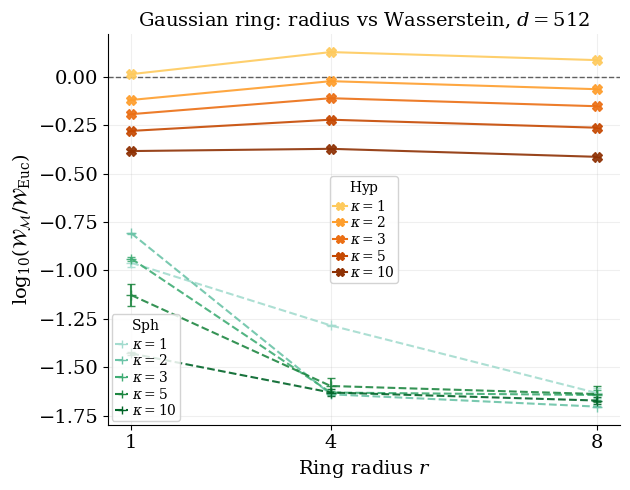

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib as mpl

# ============================================================
# User settings
# ============================================================

PERF_COL = "test_sample/sinkhorn_knopp"
VGG_COL = "test_sample/volume_scaling_gap_target_minus_pred"

DIM_COL = "dim"
MANIFOLD_COL = "manifold"
CURV_COL = "curvature"
RADIUS_COL = "radius_x1"

EUCLIDEAN_NAME = "euclidean"
POINCARE_NAME = "poincare"
SPHERE_NAME = "sphere"

SPHERE_DIM_MINUS_ONE = True

ERROR_BAR = "sem"        # "sem" or "std"
CURVATURE_ORDER = "abs"

LEGEND_FONTSIZE = 10
LEGEND_FRAME_ALPHA = 0.85


# ============================================================
# Helpers
# ============================================================

def signed_log1p(x):
    """Signed log transform: keeps sign, handles zero, compresses large values."""
    return np.sign(x) * np.log10(1 + np.abs(x))


def error_value(x, kind="sem"):
    x = pd.Series(x).replace([np.inf, -np.inf], np.nan).dropna()

    if len(x) <= 1:
        return 0.0

    if kind == "std":
        return x.std(ddof=1)

    if kind == "sem":
        return x.std(ddof=1) / np.sqrt(len(x))

    return 0.0


def nice_dim_label(x):
    if pd.isna(x):
        return ""
    if float(x).is_integer():
        return str(int(x))
    return f"{x:g}"


def nice_curv_label(x):
    if pd.isna(x):
        return "NA"
    try:
        return f"{float(x):g}"
    except Exception:
        return str(x)


def display_manifold_name(m):
    if m == POINCARE_NAME:
        return "Hyperbolic"
    if m == SPHERE_NAME:
        return "Spherical"
    if m == EUCLIDEAN_NAME:
        return "Euclidean"
    return str(m)


def ordered_curvatures(values, order="abs"):
    values = pd.Series(values).dropna().unique()

    def sort_key(x):
        try:
            x_float = float(x)

            if order == "abs":
                return (abs(x_float), x_float)

            if order == "numeric":
                return (x_float,)

        except Exception:
            pass

        return (str(x),)

    return sorted(values, key=sort_key)


def ordered_manifolds(values):
    preferred_order = [POINCARE_NAME, SPHERE_NAME, EUCLIDEAN_NAME]
    values = list(pd.Series(values).dropna().unique())

    ordered = [m for m in preferred_order if m in values]
    ordered += [m for m in values if m not in ordered]

    return ordered


def add_grouped_curvature_legends(
    ax,
    specs,
    hyp_loc="upper right",
    sph_loc="center right",
    fontsize=LEGEND_FONTSIZE,
):
    """
    Adds two compact legends:
    one for Hyperbolic curvatures and one for Spherical curvatures.
    """

    hyp_handles, hyp_labels = [], []
    sph_handles, sph_labels = [], []

    for spec in specs:
        handle = plt.Line2D(
            [0],
            [0],
            color=spec["color"],
            marker=spec["marker"],
            linestyle=spec["linestyle"],
            linewidth=1.5,
            markersize=6,
        )

        label = rf"$\kappa={nice_curv_label(spec['curvature'])}$"

        if spec["manifold"] == POINCARE_NAME:
            hyp_handles.append(handle)
            hyp_labels.append(label)

        elif spec["manifold"] == SPHERE_NAME:
            sph_handles.append(handle)
            sph_labels.append(label)

    hyp_legend = None
    sph_legend = None

    if hyp_handles:
        hyp_legend = ax.legend(
            hyp_handles,
            hyp_labels,
            title=r"$\mathrm{Hyp}$",
            loc=hyp_loc,
            frameon=True,
            framealpha=LEGEND_FRAME_ALPHA,
            fontsize=fontsize,
            title_fontsize=fontsize,
            ncol=1,
            handlelength=1.0,
            handletextpad=0.25,
            labelspacing=0.12,
            borderpad=0.22,
            borderaxespad=0.25,
            markerscale=0.85,
        )
        ax.add_artist(hyp_legend)

    if sph_handles:
        sph_legend = ax.legend(
            sph_handles,
            sph_labels,
            title=r"$\mathrm{Sph}$",
            loc=sph_loc,
            frameon=True,
            framealpha=LEGEND_FRAME_ALPHA,
            fontsize=fontsize,
            title_fontsize=fontsize,
            ncol=1,
            handlelength=1.0,
            handletextpad=0.25,
            labelspacing=0.12,
            borderpad=0.22,
            borderaxespad=0.25,
            markerscale=0.85,
        )

    return hyp_legend, sph_legend


# ============================================================
# Data preparation
# ============================================================

def prepare_gaussian_ring_dataframe(df):
    """
    Adds:
    - compare_dim
    - Euclidean baselines per dimension and radius
    - log-relative Wasserstein wrt Euclidean
    - signed-log VGG gap wrt Euclidean
    """

    df = df.copy()

    # Keep only Gaussian-ring rows if the column exists
    if "x1_dist" in df.columns:
        df = df[
            df["x1_dist"].astype(str).str.lower().str.contains("ring", na=False)
        ].copy()

    for col in [PERF_COL, VGG_COL, DIM_COL, CURV_COL, RADIUS_COL]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    # Comparable intrinsic dimension
    df["compare_dim"] = df[DIM_COL]

    if SPHERE_DIM_MINUS_ONE:
        is_sphere = df[MANIFOLD_COL].eq(SPHERE_NAME)
        df.loc[is_sphere, "compare_dim"] = df.loc[is_sphere, DIM_COL] - 1

    # Euclidean baseline at same dimension and same radius
    euc = (
        df[df[MANIFOLD_COL].eq(EUCLIDEAN_NAME)]
        .groupby(["compare_dim", RADIUS_COL], as_index=False)
        .agg(
            euc_wasserstein=(PERF_COL, "mean"),
            euc_vgg=(VGG_COL, "mean"),
        )
    )

    euc["euc_vgg"] = euc["euc_vgg"].fillna(0.0)

    df = df.merge(
        euc,
        on=["compare_dim", RADIUS_COL],
        how="left",
    )

    # Relative Wasserstein performance
    df["rel_wasserstein"] = df[PERF_COL] / df["euc_wasserstein"]
    df["log_rel_wasserstein"] = np.log10(df["rel_wasserstein"])

    # VGG relative to Euclidean
    df["vgg_gap_vs_euc"] = df[VGG_COL] - df["euc_vgg"]
    df["signed_log_vgg_gap"] = signed_log1p(df["vgg_gap_vs_euc"])

    return df


def summarize_gaussian_ring_by_radius(df_ring):
    """
    Averages over seeds for each:
        dimension × manifold × curvature × radius
    """

    plot_df = df_ring[
        ~df_ring[MANIFOLD_COL].eq(EUCLIDEAN_NAME)
    ].copy()

    group_cols = ["compare_dim", MANIFOLD_COL, CURV_COL, RADIUS_COL]

    rows = []

    for keys, sub in plot_df.groupby(group_cols, dropna=False):
        compare_dim, manifold, curvature, radius = keys

        vgg = sub["signed_log_vgg_gap"].replace([np.inf, -np.inf], np.nan).dropna()
        wass = sub["log_rel_wasserstein"].replace([np.inf, -np.inf], np.nan).dropna()

        rows.append({
            "compare_dim": compare_dim,
            MANIFOLD_COL: manifold,
            CURV_COL: curvature,
            RADIUS_COL: radius,

            "vgg_mean": vgg.mean(),
            "vgg_err": error_value(vgg, ERROR_BAR),
            "vgg_n": len(vgg),

            "wass_mean": wass.mean(),
            "wass_err": error_value(wass, ERROR_BAR),
            "wass_n": len(wass),
        })

    return pd.DataFrame(rows)


# ============================================================
# Plot styling
# ============================================================

def get_ring_style_specs(summary_dim):
    marker_map = {
        POINCARE_NAME: "X",
        SPHERE_NAME: "+",
    }

    line_map = {
        POINCARE_NAME: "solid",
        SPHERE_NAME: "dashed",
    }

    manifold_cmap_map = {
        POINCARE_NAME: plt.cm.YlOrBr,
        SPHERE_NAME: plt.cm.BuGn,
    }

    manifolds = ordered_manifolds(summary_dim[MANIFOLD_COL])
    curvatures = ordered_curvatures(summary_dim[CURV_COL], order=CURVATURE_ORDER)

    curvature_color_map = {}

    for manifold in manifolds:
        manifold_curvatures = ordered_curvatures(
            summary_dim.loc[summary_dim[MANIFOLD_COL].eq(manifold), CURV_COL],
            order=CURVATURE_ORDER,
        )

        cmap = manifold_cmap_map.get(manifold, plt.cm.viridis)
        color_positions = np.linspace(0.35, 0.9, max(len(manifold_curvatures), 1))

        for i, curvature in enumerate(manifold_curvatures):
            curvature_color_map[(manifold, curvature)] = cmap(color_positions[i])

    specs = []

    for manifold in manifolds:
        for curvature in curvatures:
            sub = summary_dim[
                summary_dim[MANIFOLD_COL].eq(manifold)
                & summary_dim[CURV_COL].eq(curvature)
            ].copy()

            if sub.empty:
                continue

            specs.append({
                "sub": sub.sort_values(RADIUS_COL),
                "color": curvature_color_map.get((manifold, curvature), "C0"),
                "marker": marker_map.get(manifold, "o"),
                "linestyle": line_map.get(manifold, "solid"),
                "manifold": manifold,
                "curvature": curvature,
            })

    return specs


def get_ring_dimension_subset(ring_summary, compare_dim):
    summary_dim = ring_summary[
        ring_summary["compare_dim"].eq(compare_dim)
    ].copy()

    if summary_dim.empty:
        available_dims = sorted(ring_summary["compare_dim"].dropna().unique())
        raise ValueError(
            f"No data found for compare_dim={compare_dim}. "
            f"Available dimensions: {available_dims}"
        )

    return summary_dim


def format_radius_axis(ax, summary_dim):
    radii = sorted(summary_dim[RADIUS_COL].dropna().unique())
    ax.set_xticks(radii)
    ax.xaxis.set_major_formatter(mticker.ScalarFormatter())


# ============================================================
# Plot 1: radius vs VGG
# ============================================================

def plot_gaussian_ring_radius_vgg(
    ring_summary,
    compare_dim,
    figsize=(6.4, 5.0),
    hyp_legend_loc="upper right",
    sph_legend_loc="center right",
):
    """
    Gaussian ring plot for one comparable dimension.

    x-axis:
        ring radius

    y-axis:
        signed-log VGG gap relative to Euclidean
    """

    summary_dim = get_ring_dimension_subset(ring_summary, compare_dim)
    specs = get_ring_style_specs(summary_dim)

    fig, ax = plt.subplots(figsize=figsize)

    for spec in specs:
        sub = spec["sub"]

        ax.errorbar(
            sub[RADIUS_COL],
            sub["vgg_mean"],
            yerr=sub["vgg_err"],
            fmt=spec["marker"],
            color=spec["color"],
            markersize=7,
            capsize=3,
            linewidth=1.5,
            alpha=0.9,
            linestyle=spec["linestyle"],
        )

    ax.axhline(0, color="black", linewidth=1, linestyle="--", alpha=0.6)

    format_radius_axis(ax, summary_dim)

    ax.set_title(rf"Gaussian ring: radius vs VGG, $d={nice_dim_label(compare_dim)}$")
    ax.set_xlabel(r"Ring radius $r$")
    ax.set_ylabel(
        r"$\mathrm{sgn}(\Delta\mathrm{VGG})"
        r"\,\log_{10}\!\left(1 + |\Delta\mathrm{VGG}|\right)$"
    )

    ax.text(
        0.02,
        0.02,
        r"Euclidean baseline: $\Delta\mathrm{VGG}=0$",
        transform=ax.transAxes,
        fontsize=12,
        va="bottom",
        ha="left",
    )

    ax.grid(alpha=0.2)

    add_grouped_curvature_legends(
        ax,
        specs,
        hyp_loc=hyp_legend_loc,
        sph_loc=sph_legend_loc,
        fontsize=LEGEND_FONTSIZE,
    )

    fig.tight_layout()

    return fig, ax


# ============================================================
# Plot 2: radius vs Wasserstein
# ============================================================

def plot_gaussian_ring_radius_wasserstein(
    ring_summary,
    compare_dim,
    figsize=(6.4, 5.0),
    hyp_legend_loc="upper right",
    sph_legend_loc="center right",
):
    """
    Gaussian ring plot for one comparable dimension.

    x-axis:
        ring radius

    y-axis:
        log-relative Wasserstein relative to Euclidean
    """

    summary_dim = get_ring_dimension_subset(ring_summary, compare_dim)
    specs = get_ring_style_specs(summary_dim)

    fig, ax = plt.subplots(figsize=figsize)

    for spec in specs:
        sub = spec["sub"]

        ax.errorbar(
            sub[RADIUS_COL],
            sub["wass_mean"],
            yerr=sub["wass_err"],
            fmt=spec["marker"],
            color=spec["color"],
            markersize=7,
            capsize=3,
            linewidth=1.5,
            alpha=0.9,
            linestyle=spec["linestyle"],
        )

    ax.axhline(0, color="black", linewidth=1, linestyle="--", alpha=0.6)

    format_radius_axis(ax, summary_dim)

    ax.set_title(rf"Gaussian ring: radius vs Wasserstein, $d={nice_dim_label(compare_dim)}$")
    ax.set_xlabel(r"Ring radius $r$")
    ax.set_ylabel(
        r"$\log_{10}\!\left(\mathcal{W}_{\mathcal{M}}"
        r"/\mathcal{W}_{\mathrm{Euc}}\right)$"
    )

    # ax.text(
    #     0.02,
    #     0.02,
    #     r"$>0$: worse than Euclidean" "\n" r"$<0$: better than Euclidean",
    #     transform=ax.transAxes,
    #     fontsize=12,
    #     va="bottom",
    #     ha="left",
    # )

    ax.grid(alpha=0.2)

    add_grouped_curvature_legends(
        ax,
        specs,
        hyp_loc=hyp_legend_loc,
        sph_loc=sph_legend_loc,
        fontsize=LEGEND_FONTSIZE,
    )

    fig.tight_layout()

    return fig, ax


# ============================================================
# Usage
# ============================================================

# df = pd.read_csv("metrics(2).csv")

ring_df = prepare_gaussian_ring_dataframe(metrics_gaussian_ring)
ring_summary = summarize_gaussian_ring_by_radius(ring_df)

for dim in sorted(ring_summary["compare_dim"].dropna().unique()):
    fig_wass, ax_wass = plot_gaussian_ring_radius_wasserstein(
        ring_summary,
        compare_dim=dim,
        hyp_legend_loc="center",
        sph_legend_loc="lower left",
    )
    plt.show()
    # fig_vgg, ax_vgg = plot_gaussian_ring_radius_vgg(
    #     ring_summary,
    #     compare_dim=dim,
    #     hyp_legend_loc="upper right",
    #     sph_legend_loc="center right",
    # )
    # plt.show()